In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sro_sto_plume import microscopy as mic

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Target Microscopy Surface Roughness Review

This notebook aggregates the ROI definitions used during microscopy QA, renders each height map with the inspection polygons, and summarizes standard roughness metrics (Ra, Rq, Rz, mean height). Use the sections below to:

1. Configure scan areas and regions of interest (ROIs).
2. Inspect individual scans to sanity-check the polygons and roughness calculations.
3. Combine all scans for comparisons across treatments, scan areas, and ROI fragments.
4. Visualize the distributions and trends in multiple complementary ways (line plots, heatmaps, violins, PCA, etc.).

In [43]:
# --- 1. Configuration and ROI catalog ---
DATA_ROOT = Path("../data/TargetMicroscopy/selected")

# Map each scan area to the ROIs we want to analyze. Each entry is either
# (polygon, descriptive label) or a dict with "polygon" and optional "label" keys.
combined_sample_dict = {
    'Area0': [
        ([(0.0, 0.0), (830.0, 0.0), (830.0, 830.0), (0.0, 830.0)], 'Area0-Sanded'),
    ],
    'Area1': [
        ([(5.0, 5.0), (830.0, 5.0), (830.0, 830.0), (5.0, 830.0)], 'Area1-Avg'),
        ([(5.0, 5.0), (410.0, 5.0), (410.0, 830.0), (5.0, 830.0)], 'Area1-G1'),
        ([(550.0, 5.0), (830.0, 5.0), (830.0, 830.0), (550.0, 830.0)], 'Area1-Sanded'),
        ([(5.0, 5.0), (400.0, 5.0), (410.0, 350.0), (5.0, 200.0)], 'Area1-G1-small'),
        ([(500.0, 400.0), (830.0, 500.0), (830.0, 830.0), (550.0, 830.0)], 'Area1-Sanded-small'),
    ],
    'Area2': [
        ([(5.0, 5.0), (830.0, 5.0), (830.0, 830.0), (5.0, 830.0)], 'Area2-Avg'),
        ([(500.0, 5.0), (830.0, 5.0), (830.0, 830.0), (500.0, 830.0)], 'Area2-Sanded-1'),
        ([(450.0, 0.0), (830.0, 0.0), (830.0, 830.0), (550.0, 830.0)], 'Area2-Sanded-2'),
        ([(5.0, 5.0), (310.0, 5.0), (310.0, 830.0), (5.0, 830.0)], 'Area2-G2'),
        ([(5.0, 650.0), (150.0, 400.0), (280.0, 830.0), (5.0, 830.0)], 'Area2-G2-small'),
    ],
    'Area3': [
        ([(5.0, 5.0), (830.0, 5.0), (830.0, 830.0), (5.0, 830.0)], 'Area3-Avg'),
        ([(5.0, 5.0), (340.0, 5.0), (360.0, 220.0), (5.0, 830.0)], 'Area3-G3-1'),
        ([(520.0, 5.0), (830.0, 5.0), (830.0, 400.0), (450.0, 400.0)], 'Area3-G3-2'),
    ],
    'Area4': [
        ([(5.0, 5.0), (830.0, 5.0), (830.0, 830.0), (5.0, 830.0)], 'Area4-Avg'),
        ([(5.0, 5.0), (830.0, 5.0), (830.0, 180.0), (5.0, 270.0)], 'Area4-Sanded'),
        ([(100.0, 120.0), (830.0, 100.0), (800.0, 180.0), (5.0, 270.0)], 'Area4-Sanded-small'),
        ([(5.0, 330.0), (830.0, 230.0), (830.0, 830.0), (5.0, 830.0)], 'Area4-G4'),
    ],
    'Area5': [
        ([(5.0, 5.0), (830.0, 5.0), (830.0, 830.0), (5.0, 830.0)], 'Area5-Avg'),
        ([(5.0, 180.0), (830.0, 80.0), (830.0, 830.0), (5.0, 830.0)], 'Area5-G5'),
        ([(5.0, 5.0), (500.0, 5.0), (500.0, 30.0), (5.0, 100.0)], 'Area5-Sanded'),
    ],
}

# Select which scan areas to inspect in detail above and beyond the combined analysis.
AREAS_TO_INSPECT = list(combined_sample_dict.keys())  # edit this list to focus on specific scans



## 2. Per-scan inspection

The cell below loops through ``AREAS_TO_INSPECT`` and, for each scan area:

- renders the height maps with ROI overlays,
- computes ``Ra``, ``Rq``, ``Rz``, and mean height for every ROI,
- prints a tidy summary table for quick QA.

Adjust ``AREAS_TO_INSPECT`` above if you want to restrict the inspection to a subset of scans.

=== Area0 ===


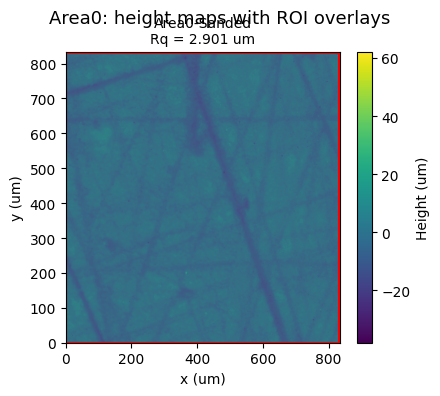

,label,treatment,Ra,Rq,Rz,mean
0,Area0-Sanded,Sanded,2.195874,2.900911,100.347,0.003759


=== Area1 ===


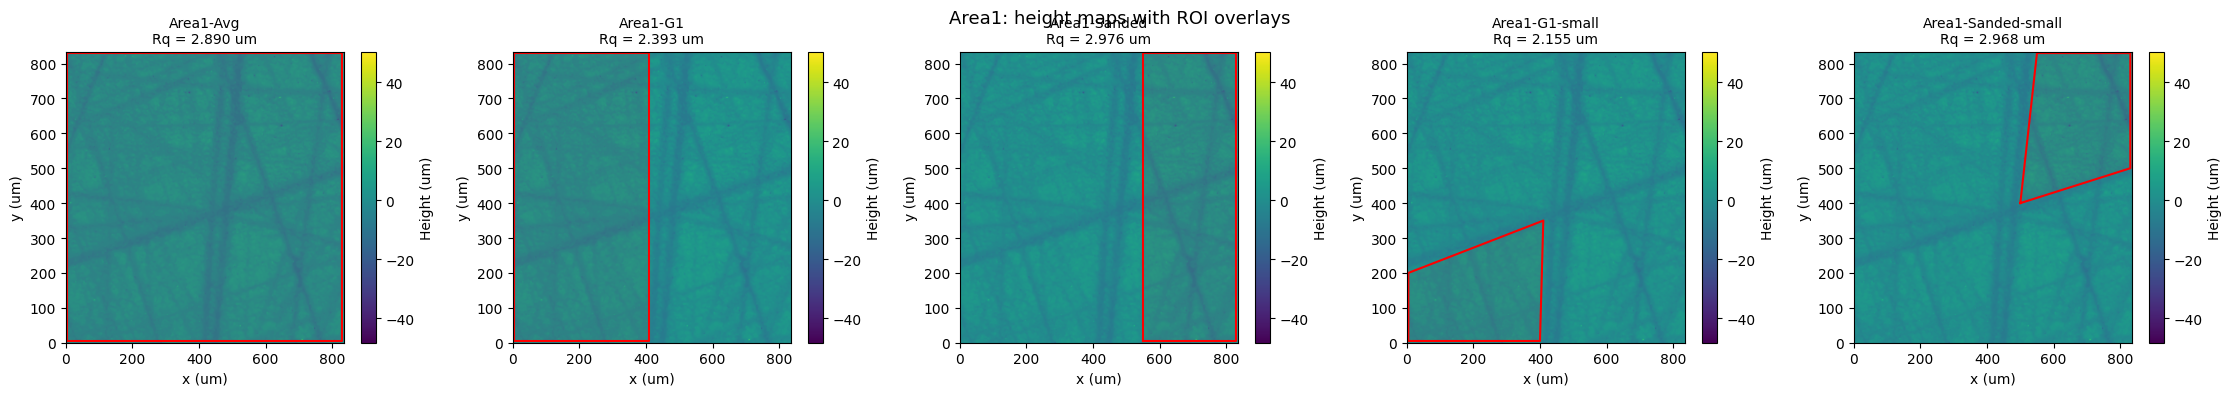

,label,treatment,Ra,Rq,Rz,mean
0,Area1-Avg,Avg,2.295172,2.890193,98.843,0.005795
1,Area1-G1,G1,1.897893,2.392523,78.711,0.260090
2,Area1-Sanded,Sanded,2.350261,2.975982,98.843,0.330532
3,Area1-G1-small,G1,1.730763,2.154590,51.540,0.832850
4,Area1-Sanded-small,Sanded,2.267781,2.968353,98.843,0.766868


=== Area2 ===


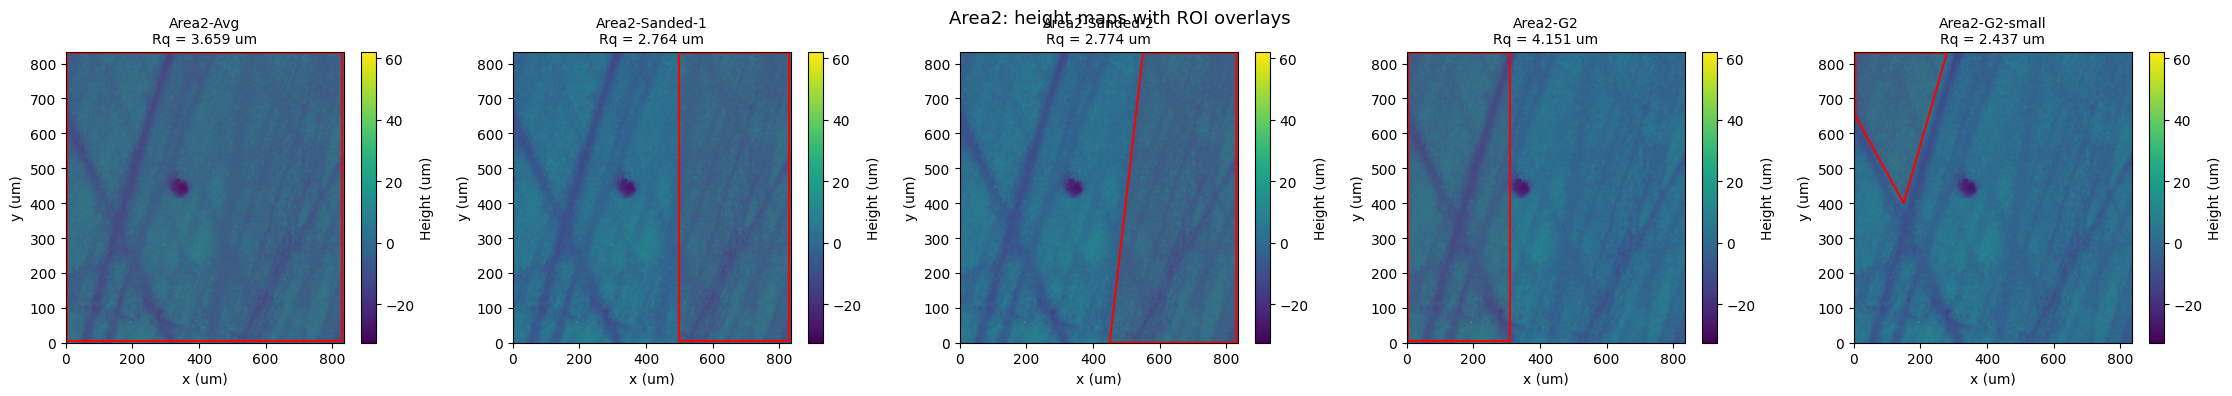

,label,treatment,Ra,Rq,Rz,mean
0,Area2-Avg,Avg,2.751315,3.659318,93.624,-0.009098
1,Area2-Sanded-1,Sanded,2.140675,2.763803,76.978,-0.247006
2,Area2-Sanded-2,Sanded,2.151752,2.773639,76.978,-0.236850
3,Area2-G2,G2,3.347019,4.151044,86.520,-0.198666
4,Area2-G2-small,G2,1.885455,2.437276,57.084,1.589005


=== Area3 ===


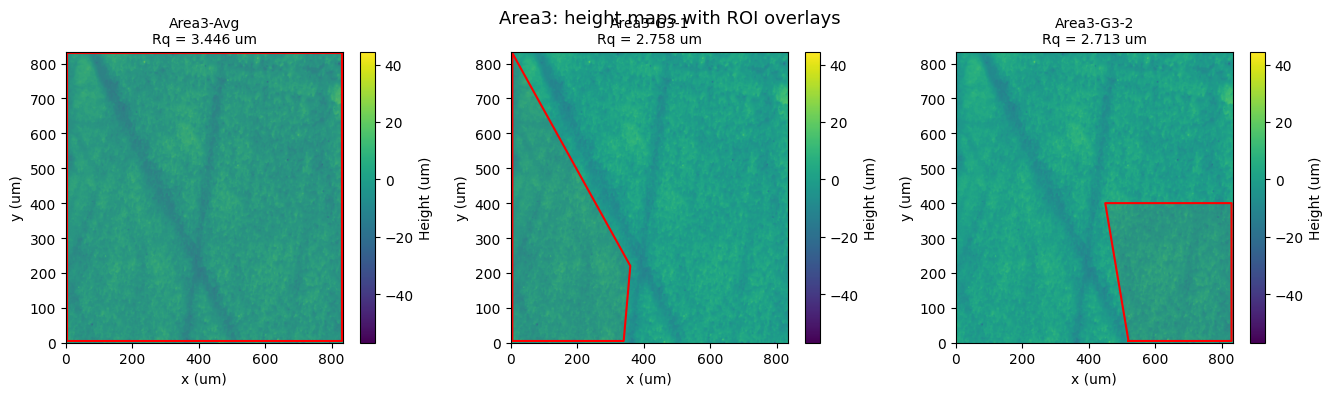

,label,treatment,Ra,Rq,Rz,mean
0,Area3-Avg,Avg,2.672869,3.446153,99.782,0.007171
1,Area3-G3-1,G3,2.172645,2.758066,77.378,0.793076
2,Area3-G3-2,G3,2.156294,2.713288,81.759,0.472551


=== Area4 ===


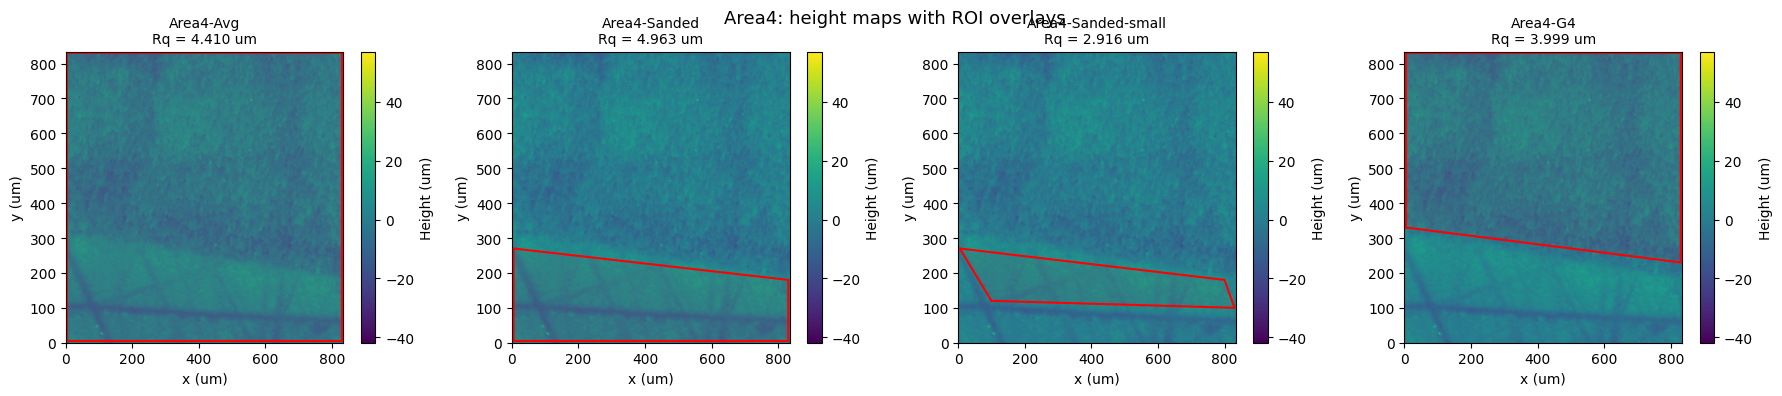

,label,treatment,Ra,Rq,Rz,mean
0,Area4-Avg,Avg,3.543408,4.410484,99.088,0.015428
1,Area4-Sanded,Sanded,3.994351,4.963203,98.932,1.304500
2,Area4-Sanded-small,Sanded,2.323374,2.916277,50.682,4.900463
3,Area4-G4,G4,3.206392,3.999379,93.675,-0.671242


=== Area5 ===


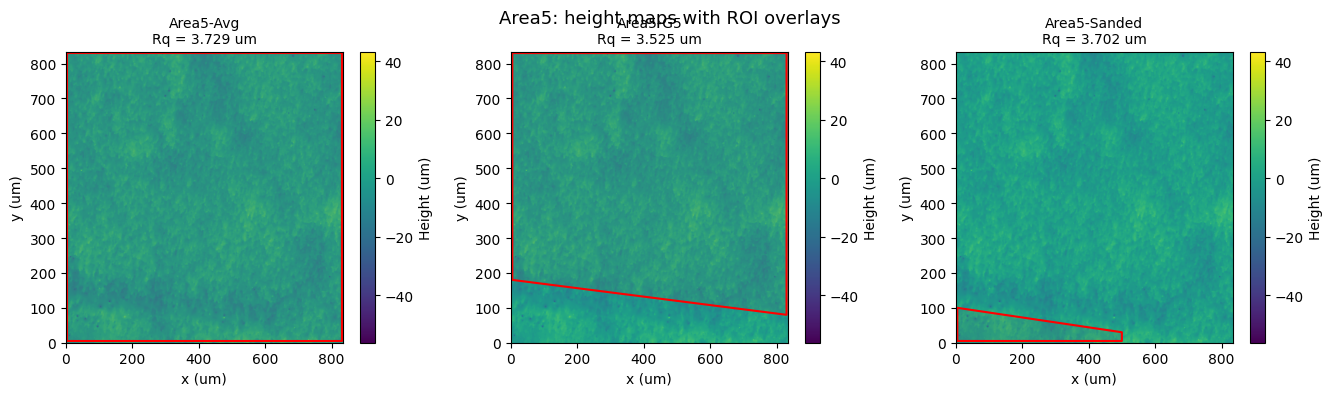

,label,treatment,Ra,Rq,Rz,mean
0,Area5-Avg,Avg,2.942933,3.729138,99.547,-0.018197
1,Area5-G5,G5,2.784789,3.525388,99.547,0.079792
2,Area5-Sanded,Sanded,2.890805,3.701887,85.768,2.133581


In [48]:
per_area_tables = {}

for area in AREAS_TO_INSPECT:
    print(f"=== {area} ===")
    surfaces = mic.build_surfaces(combined_sample_dict, area=area, data_root=DATA_ROOT)

    results, fig = mic.analyze_surfaces(
        surfaces,
        polygon_unit='um',
        roughness_unit='um',
        xy_unit='um',
        z_unit='um',
        max_cols=5,
    )
    fig.suptitle(f"{area}: height maps with ROI overlays", fontsize=13)
    plt.show()

    single_df = pd.DataFrame(results)
    split_cols = single_df['label'].str.split('-', expand=True)
    split_cols = split_cols.reindex(columns=range(3))  # force columns 0,1,2
    split_cols = split_cols.fillna('unknown')

    single_df['area'] = split_cols[0]
    single_df['treatment'] = split_cols[1]
    single_df['roi_fragment'] = split_cols[2]

    per_area_tables[area] = single_df
    display(single_df[['label', 'treatment', 'Ra', 'Rq', 'Rz', 'mean']])

## 3. Selected scan area comparison

In [49]:
selected_labels = ['Area0-Sanded', 'Area1-G1', 'Area2-G2-small', 'Area3-G3-1', 'Area4-G4', 'Area5-G5']
selected_df = pd.concat(
    [df[df['label'].isin(selected_labels)] for df in per_area_tables.values()],
    ignore_index=True
)
selected_df = selected_df.sort_values(by=['area', 'treatment', 'roi_fragment'])
display(selected_df)

,unit,polygon_unit,count,mask_pixels,mean,Ra,Rq,Rz,area,polygon,label,treatment,roi_fragment
0,um,um,1038361,1038361,0.003759,2.195874,2.900911,100.347,Area0,"[[0.0, 0.0], [830.0, 0.0], [830.0, 830.0], [0....",Area0-Sanded,Sanded,unknown
1,um,um,503461,503461,0.260090,1.897893,2.392523,78.711,Area1,"[[5.0, 5.0], [410.0, 5.0], [410.0, 830.0], [5....",Area1-G1,G1,unknown
2,um,um,108867,108867,1.589005,1.885455,2.437276,57.084,Area2,"[[5.0, 650.0], [150.0, 400.0], [280.0, 830.0],...",Area2-G2-small,G2,small
3,um,um,275000,275000,0.793076,2.172645,2.758066,77.378,Area3,"[[5.0, 5.0], [340.0, 5.0], [360.0, 220.0], [5....",Area3-G3-1,G3,1
4,um,um,684143,684143,-0.671242,3.206392,3.999379,93.675,Area4,"[[5.0, 330.0], [830.0, 230.0], [830.0, 830.0],...",Area4-G4,G4,unknown
5,um,um,870627,870627,0.079792,2.784789,3.525388,99.547,Area5,"[[5.0, 180.0], [830.0, 80.0], [830.0, 830.0], ...",Area5-G5,G5,unknown


Rq                  Ra                 Rz          
               mean std count      mean std count     mean std count
treatment                                                           
G4         3.999379 NaN     1  3.206392 NaN     1   93.675 NaN     1
G5         3.525388 NaN     1  2.784789 NaN     1   99.547 NaN     1
Sanded     2.900911 NaN     1  2.195874 NaN     1  100.347 NaN     1
G3         2.758066 NaN     1  2.172645 NaN     1   77.378 NaN     1
G2         2.437276 NaN     1  1.885455 NaN     1   57.084 NaN     1
G1         2.392523 NaN     1  1.897893 NaN     1   78.711 NaN     1

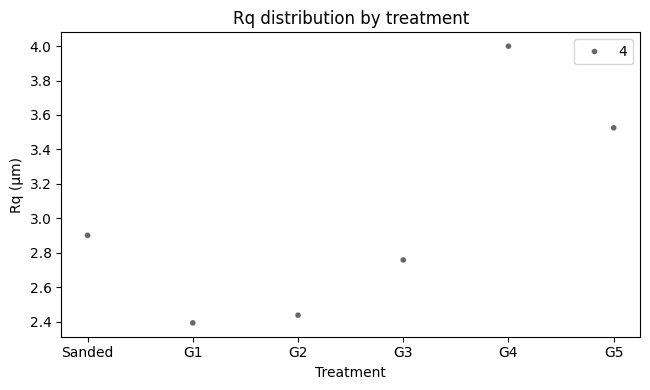

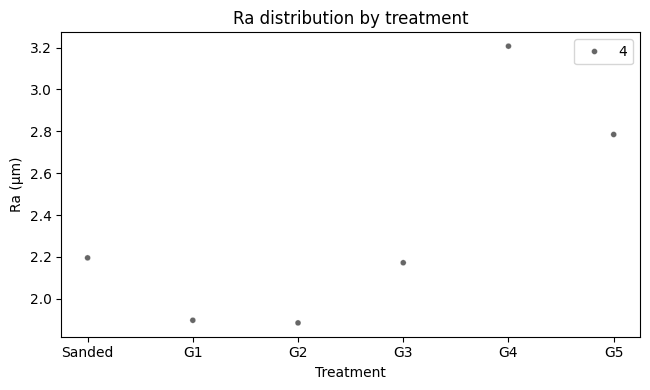

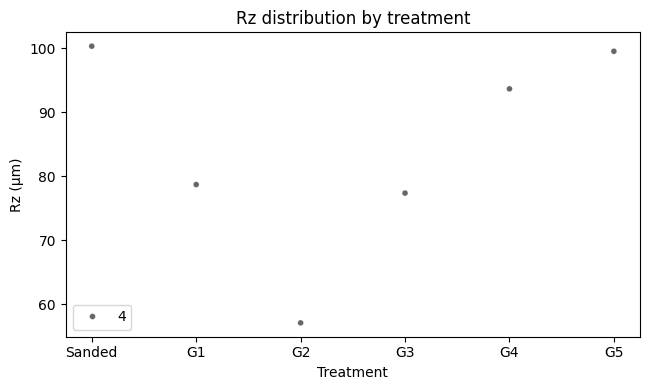

In [53]:
def summarize_and_plot(df, group_col, metrics=('Rq', 'Ra', 'Rz')):
    """Print mean/std/count tables and draw violin plots for the requested metrics."""
    summary = df.groupby(group_col)[list(metrics)].agg(['mean', 'std', 'count'])
    display(summary.sort_values((metrics[0], 'mean'), ascending=False))

    for metric in metrics:
        order = summary.index.tolist()
        fig, ax = plt.subplots(figsize=(max(6, len(order) * 1.1), 4))
        sns.scatterplot(data=df, x=group_col, y=metric, ax=ax, color='black', size=4, alpha=0.6)
        ax.set_title(f"{metric} distribution by {group_col}")
        ax.set_xlabel(group_col.capitalize())
        ax.set_ylabel(f"{metric} (µm)")
        fig.tight_layout()
        plt.show()

summarize_and_plot(selected_df, 'treatment', metrics=('Rq', 'Ra', 'Rz'))

## 4. Combined analysis across all scans

Aggregate every ROI so we can compare treatments and scan areas in a single set of plots.

Aggregated 21 ROIs across 6 scan areas.


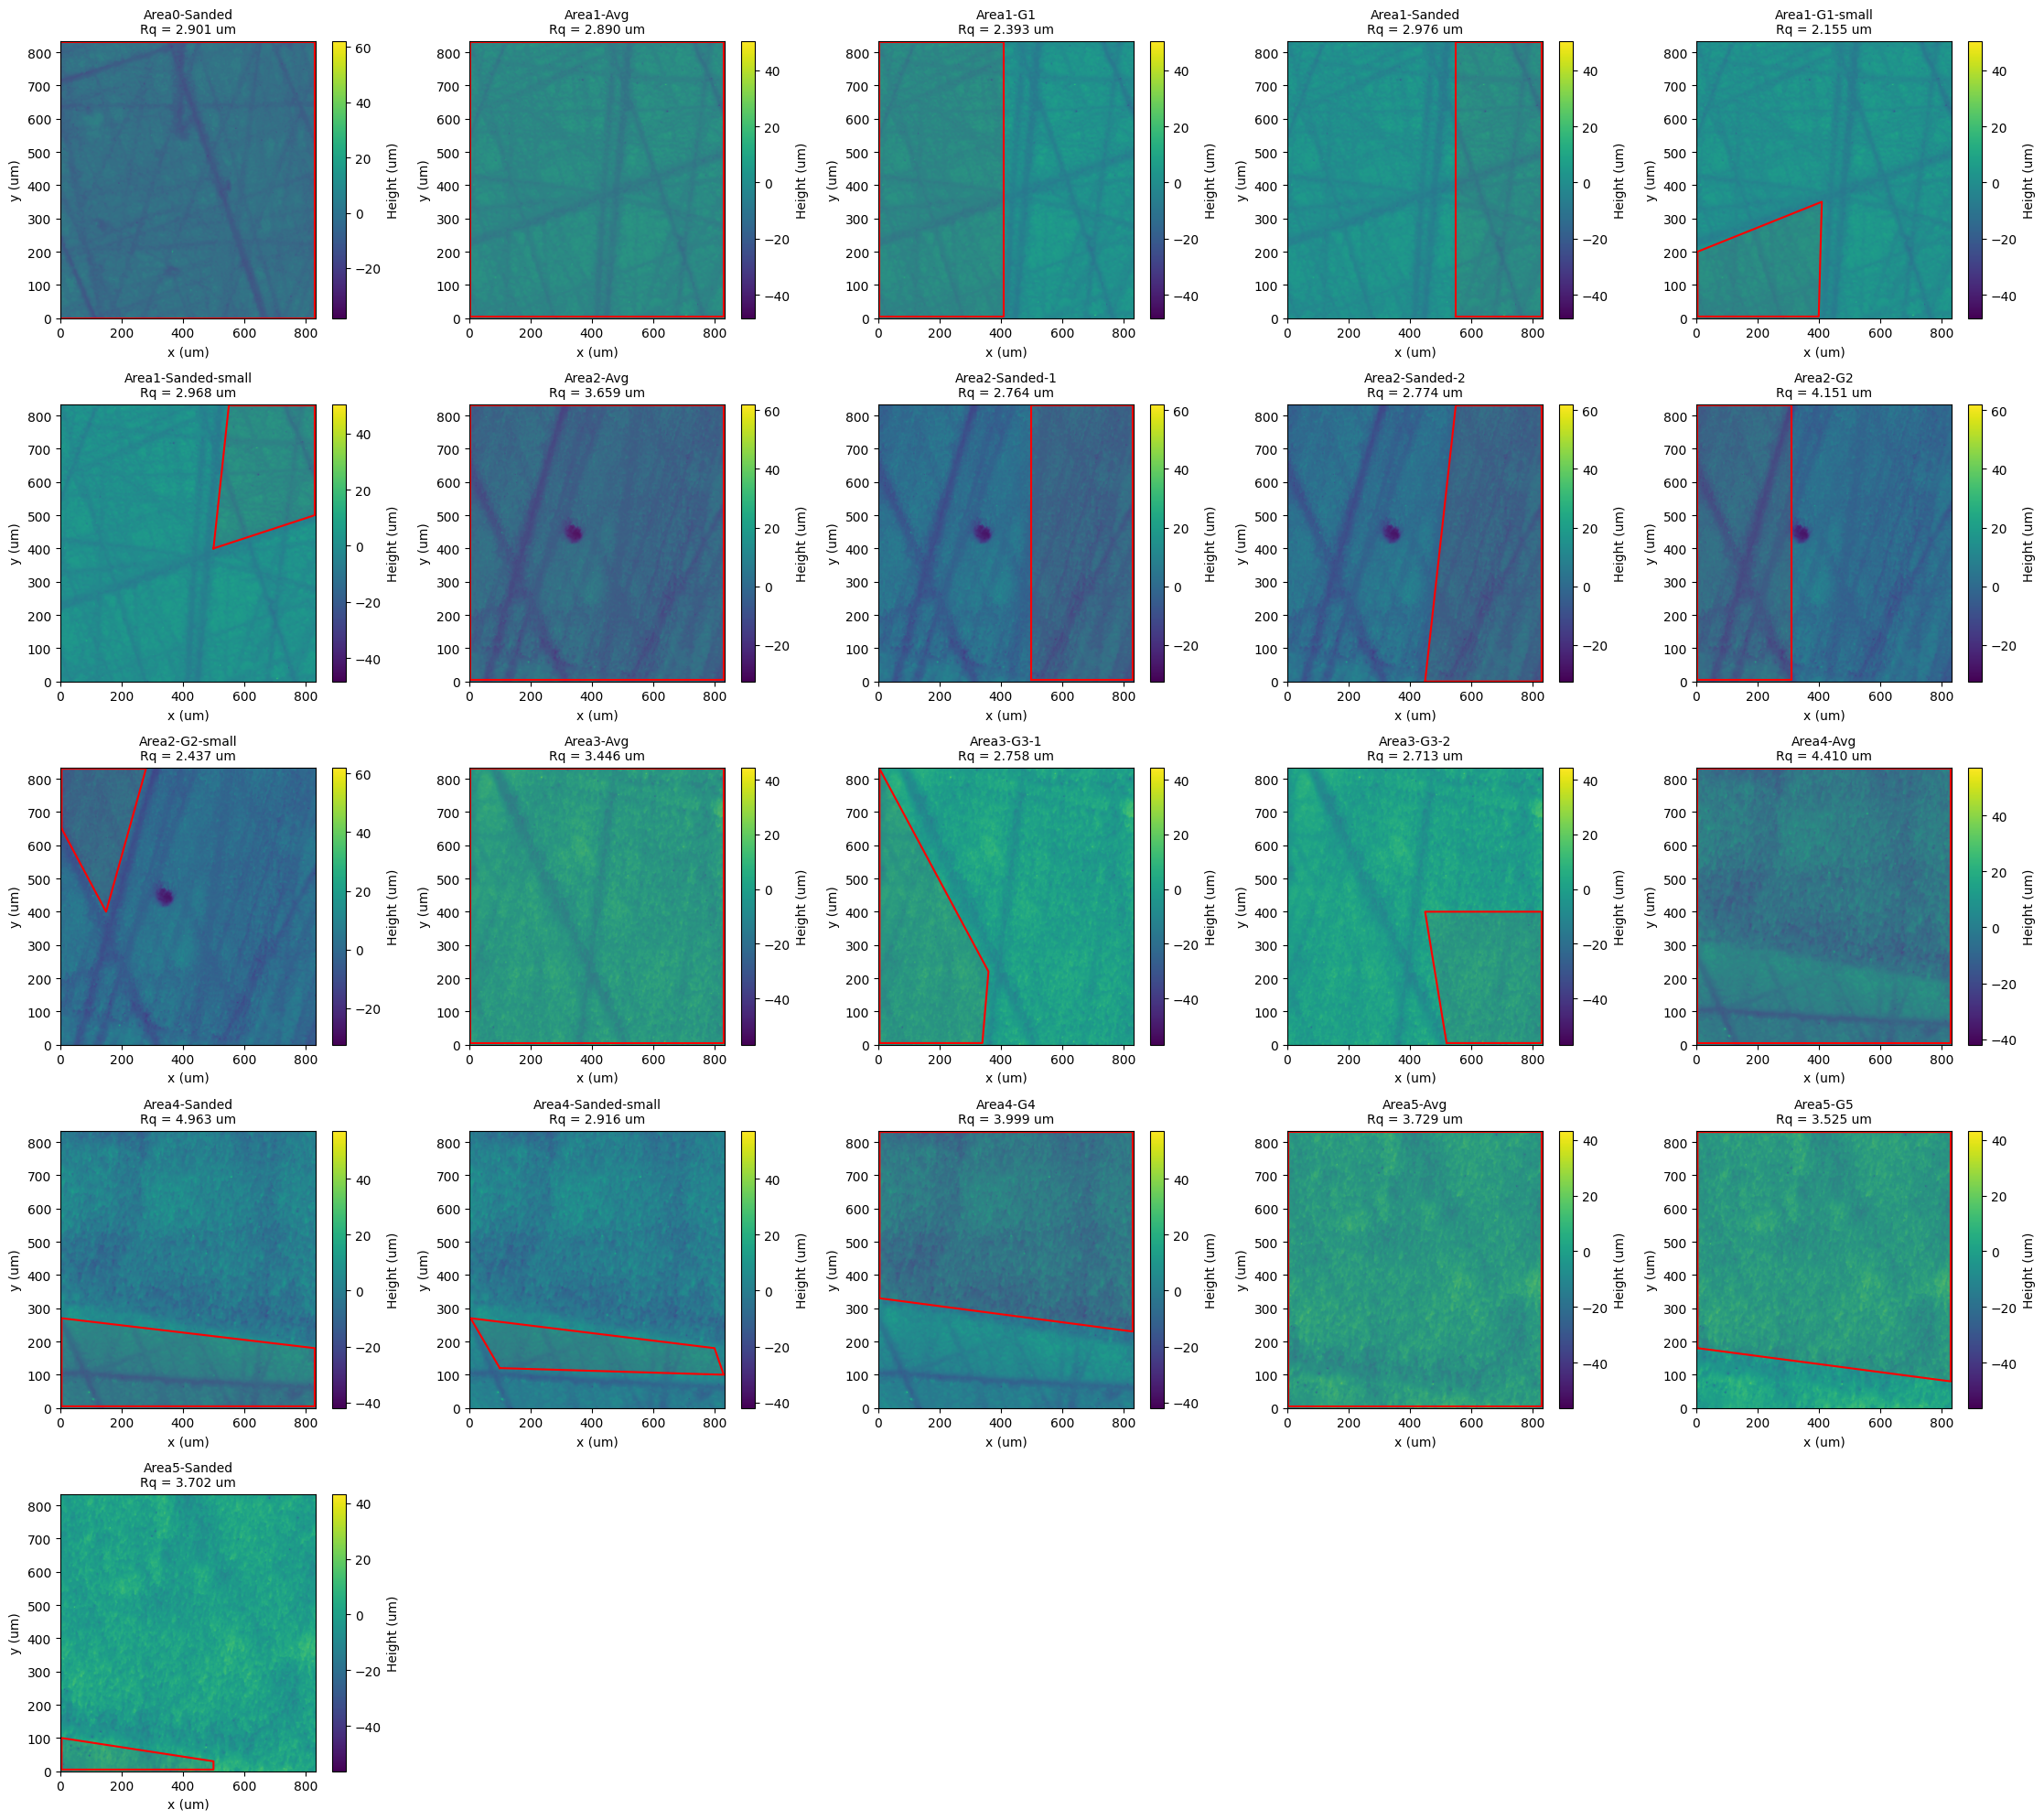

In [ ]:
combined_surfaces = mic.build_surfaces(combined_sample_dict, data_root=DATA_ROOT)
combined_results, combined_fig = mic.analyze_surfaces(
    combined_surfaces,
    polygon_unit='um',
    roughness_unit='um',
    xy_unit='um',
    z_unit='um',
    max_cols=5,
)
print(f"Aggregated {len(combined_results)} ROIs across {len(combined_sample_dict)} scan areas.")

### 4.1 Metrics table and normalization

Split labels into ``area`` / ``treatment`` / ``roi_fragment`` fields, then standardize the roughness metrics (z-scores) for fair comparisons.

In [33]:
combined_df = pd.DataFrame(combined_results)

split_cols = combined_df['label'].str.split('-', expand=True)
split_cols = split_cols.reindex(columns=range(3)).fillna('unknown')
combined_df['area'] = split_cols[0]
combined_df['treatment'] = split_cols[1]
combined_df['roi_fragment'] = split_cols[2]

combined_df = combined_df[['area', 'treatment', 'roi_fragment', 'label', 'Ra', 'Rq', 'Rz', 'mean', 'datx', 'txt']]
combined_df.sort_values(['treatment', 'area', 'roi_fragment'], inplace=True, ignore_index=True)

scaler = StandardScaler()
scaled = scaler.fit_transform(combined_df[['Ra', 'Rq', 'Rz', 'mean']])
scaled_df = pd.DataFrame(scaled, columns=['Ra_z', 'Rq_z', 'Rz_z', 'mean_z'])
combined_df = pd.concat([combined_df, scaled_df], axis=1)

display(combined_df)



,area,treatment,roi_fragment,label,Ra,Rq,Rz,mean,datx,txt,Ra_z,Rq_z,Rz_z,mean_z
0,Area1,Avg,unknown,Area1-Avg,2.295172,2.890193,98.843,0.005795,../data/TargetMicroscopy/selected/Area1.datx,../data/TargetMicroscopy/selected/Area1.txt,-0.452538,-0.508113,0.813575,-0.488247
1,Area2,Avg,unknown,Area2-Avg,2.751315,3.659318,93.624,-0.009098,../data/TargetMicroscopy/selected/Area2.datx,../data/TargetMicroscopy/selected/Area2.txt,0.335159,0.580785,0.484829,-0.500980
2,Area3,Avg,unknown,Area3-Avg,2.672869,3.446153,99.782,0.007171,../data/TargetMicroscopy/selected/Area3.datx,../data/TargetMicroscopy/selected/Area3.txt,0.199693,0.278995,0.872722,-0.487071
3,Area4,Avg,unknown,Area4-Avg,3.543408,4.410484,99.088,0.015428,../data/TargetMicroscopy/selected/Area4.datx,../data/TargetMicroscopy/selected/Area4.txt,1.702998,1.644258,0.829007,-0.480011
4,Area5,Avg,unknown,Area5-Avg,2.942933,3.729138,99.547,-0.018197,../data/TargetMicroscopy/selected/Area5.datx,../data/TargetMicroscopy/selected/Area5.txt,0.666058,0.679634,0.857920,-0.508759
5,Area1,G1,small,Area1-G1-small,1.730763,2.154590,51.540,0.832850,../data/TargetMicroscopy/selected/Area1.datx,../data/TargetMicroscopy/selected/Area1.txt,-1.427196,-1.549553,-2.166048,0.218845
6,Area1,G1,unknown,Area1-G1,1.897893,2.392523,78.711,0.260090,../data/TargetMicroscopy/selected/Area1.datx,../data/TargetMicroscopy/selected/Area1.txt,-1.138585,-1.212696,-0.454543,-0.270837
7,Area2,G2,small,Area2-G2-small,1.885455,2.437276,57.084,1.589005,../data/TargetMicroscopy/selected/Area2.datx,../data/TargetMicroscopy/selected/Area2.txt,-1.160064,-1.149336,-1.816831,0.865321
8,Area2,G2,unknown,Area2-G2,3.347019,4.151044,86.520,-0.198666,../data/TargetMicroscopy/selected/Area2.datx,../data/TargetMicroscopy/selected/Area2.txt,1.363860,1.276953,0.037347,-0.663052
9,Area3,G3,1,Area3-G3-1,2.172645,2.758066,77.378,0.793076,../data/TargetMicroscopy/selected/Area3.datx,../data/TargetMicroscopy/selected/Area3.txt,-0.664126,-0.695174,-0.538509,0.184841


### 4.2 Overview figure

Full gallery of all scans with ROI overlays and annotated ``Rq`` values.

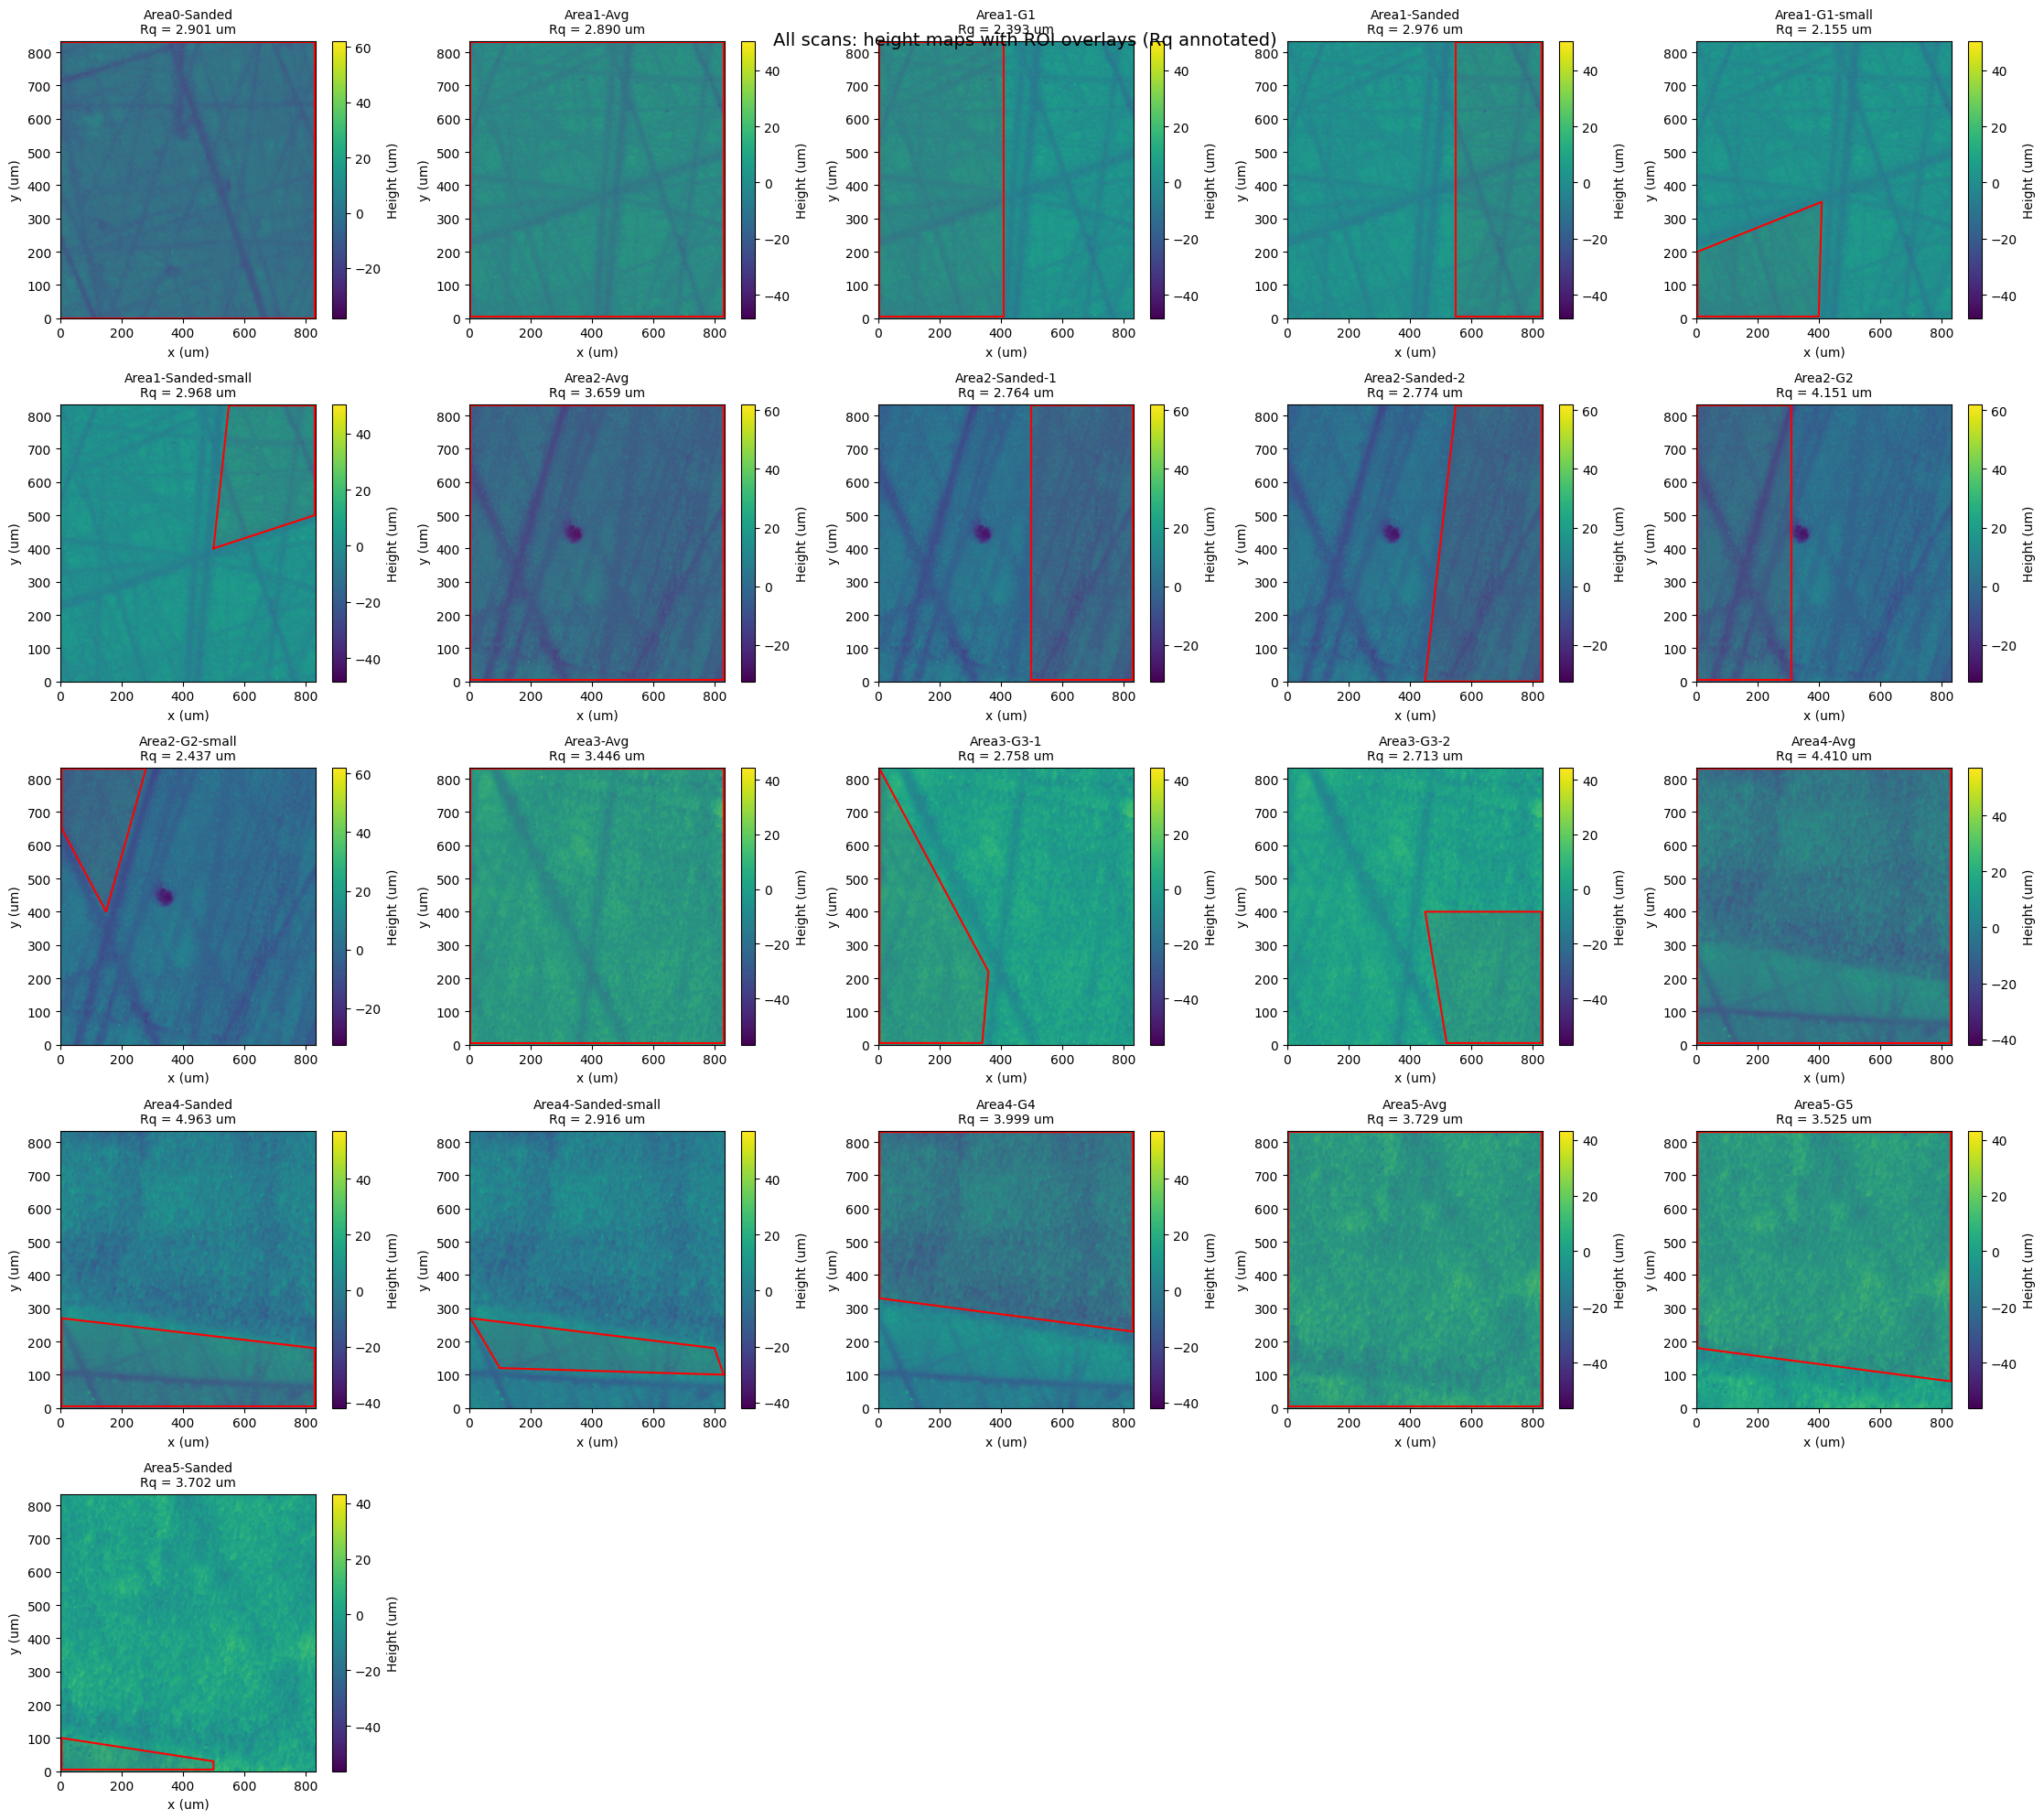

In [ ]:
combined_fig.suptitle('All scans: height maps with ROI overlays (Rq annotated)', fontsize=14)
combined_fig

### 4.3 Metric summaries by category

Summaries and violin plots for each grouping (treatment, scan area, ROI fragment).

Rq                        Ra                         Rz  \
               mean       std count      mean       std count       mean   
treatment                                                                  
G4         3.999379       NaN     1  3.206392       NaN     1  93.675000   
Avg        3.627057  0.547931     5  2.841139  0.457714     5  98.176800   
G5         3.525388       NaN     1  2.784789       NaN     1  99.547000   
G2         3.294160  1.211817     2  2.616237  1.033482     2  71.802000   
Sanded     3.245507  0.754989     8  2.539359  0.635143     8  85.921375   
G3         2.735677  0.031663     2  2.164469  0.011562     2  79.568500   
G1         2.273557  0.168244     2  1.814328  0.118179     2  65.125500   

                            
                 std count  
treatment                   
G4               NaN     1  
Avg         2.571780     5  
G5               NaN     1  
G2         20.814395     2  
Sanded     17.374517     8  
G3          3.097835     2  
G1         19.212798     2

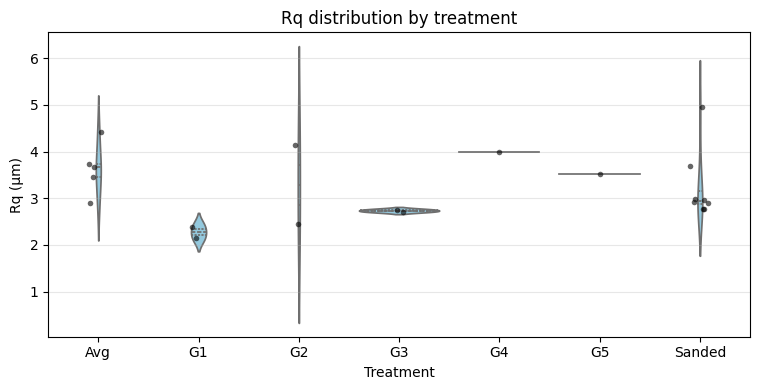

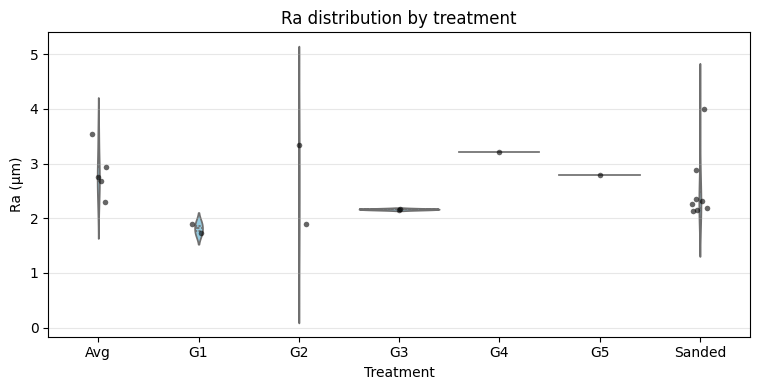

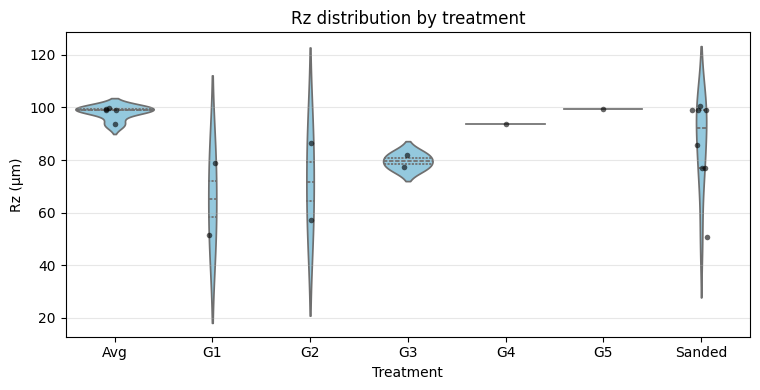

Rq                        Ra                          Rz  \
           mean       std count      mean       std count        mean   
area                                                                    
Area4  4.072336  0.865984     4  3.266881  0.707000     4   85.594250   
Area5  3.652138  0.110611     3  2.872842  0.080587     3   94.954000   
Area2  3.157016  0.717638     5  2.455243  0.591321     5   78.236800   
Area3  2.972503  0.410804     3  2.333936  0.293638     3   86.306333   
Area0  2.900911       NaN     1  2.195874       NaN     1  100.347000   
Area1  2.676328  0.378671     5  2.108374  0.276453     5   85.356000   

                        
             std count  
area                    
Area4  23.410401     4  
Area5   7.955309     3  
Area2  13.747613     5  
Area3  11.874068     3  
Area0        NaN     1  
Area1  20.816913     5

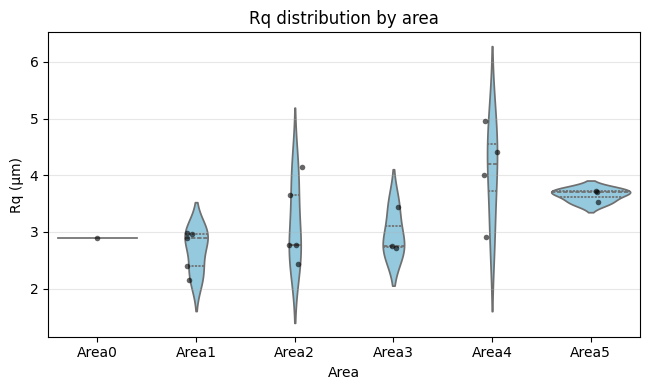

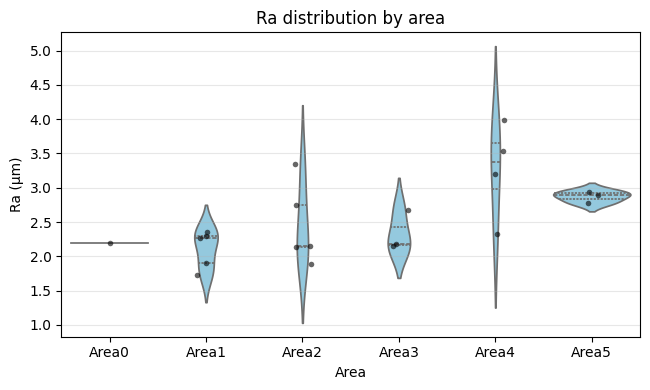

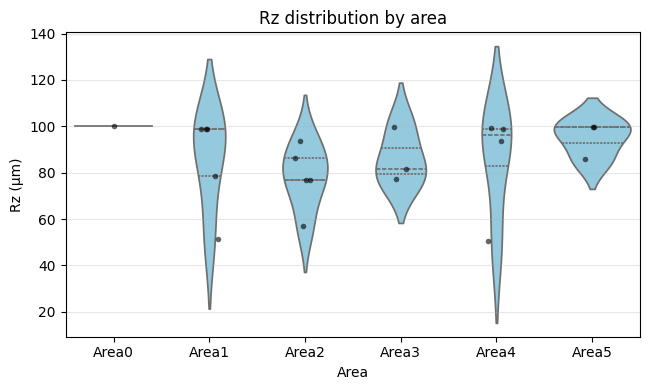

Rq                        Ra                         Rz  \
                  mean       std count      mean       std count       mean   
roi_fragment                                                                  
unknown       3.595816  0.699875    13  2.836391  0.585208    13  94.863615   
1             2.760935  0.004056     2  2.156660  0.022606     2  77.178000   
2             2.743464  0.042674     2  2.154023  0.003212     2  79.368500   
small         2.619124  0.391204     4  2.051843  0.289330     4  64.537250   

                               
                    std count  
roi_fragment                   
unknown        6.954597    13  
1              0.282843     2  
2              3.380678     2  
small         23.045838     4

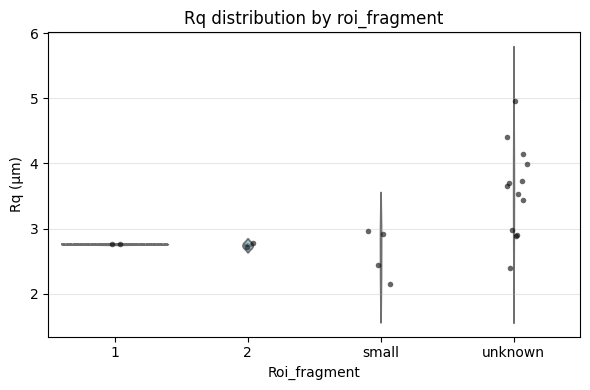

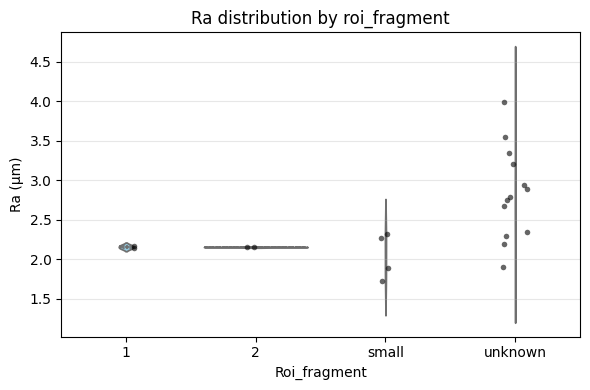

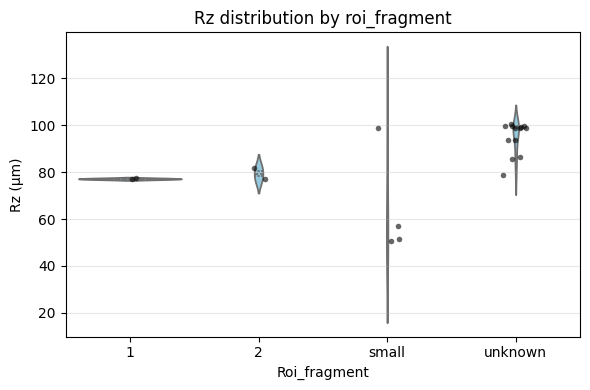

In [ ]:
def summarize_and_plot(df, group_col, metrics=('Rq', 'Ra', 'Rz')):
    """Print mean/std/count tables and draw violin plots for the requested metrics."""
    summary = df.groupby(group_col)[list(metrics)].agg(['mean', 'std', 'count'])
    display(summary.sort_values((metrics[0], 'mean'), ascending=False))

    for metric in metrics:
        order = summary.index.tolist()
        fig, ax = plt.subplots(figsize=(max(6, len(order) * 1.1), 4))
        sns.violinplot(data=df, x=group_col, y=metric,
                       order=order, inner='quartile', ax=ax, color='skyblue')
        sns.stripplot(data=df, x=group_col, y=metric,
                      order=order, ax=ax, color='black', size=4, alpha=0.6)
        ax.set_title(f"{metric} distribution by {group_col}")
        ax.set_xlabel(group_col.capitalize())
        ax.set_ylabel(f"{metric} (µm)")
        ax.grid(axis='y', alpha=0.3)
        fig.tight_layout()
        plt.show()

summarize_and_plot(combined_df, 'treatment', metrics=('Rq', 'Ra', 'Rz'))
summarize_and_plot(combined_df, 'area', metrics=('Rq', 'Ra', 'Rz'))
summarize_and_plot(combined_df, 'roi_fragment', metrics=('Rq', 'Ra', 'Rz'))

### 4.4 Line plots per metric

Track each roughness metric across ROIs in sequence.

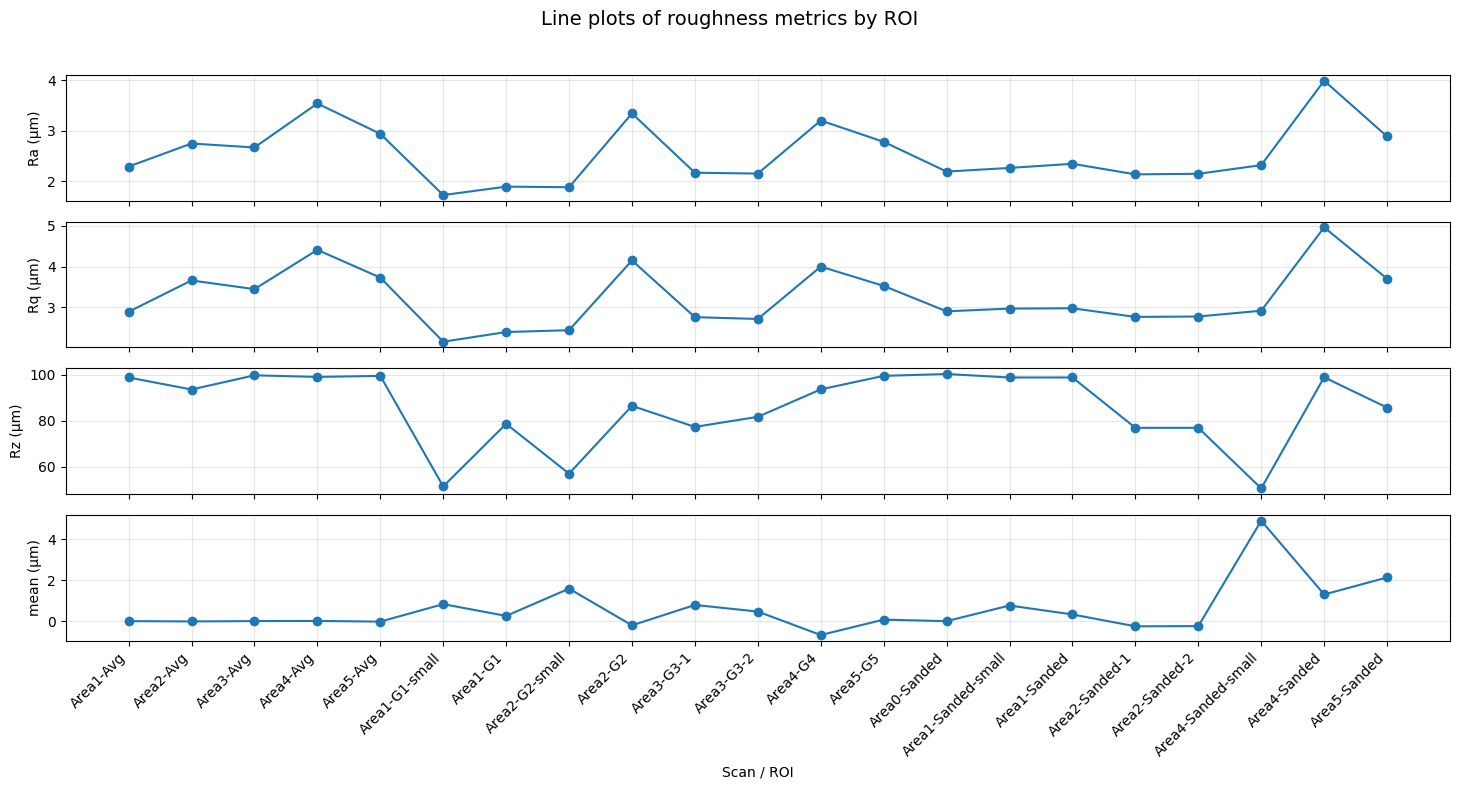

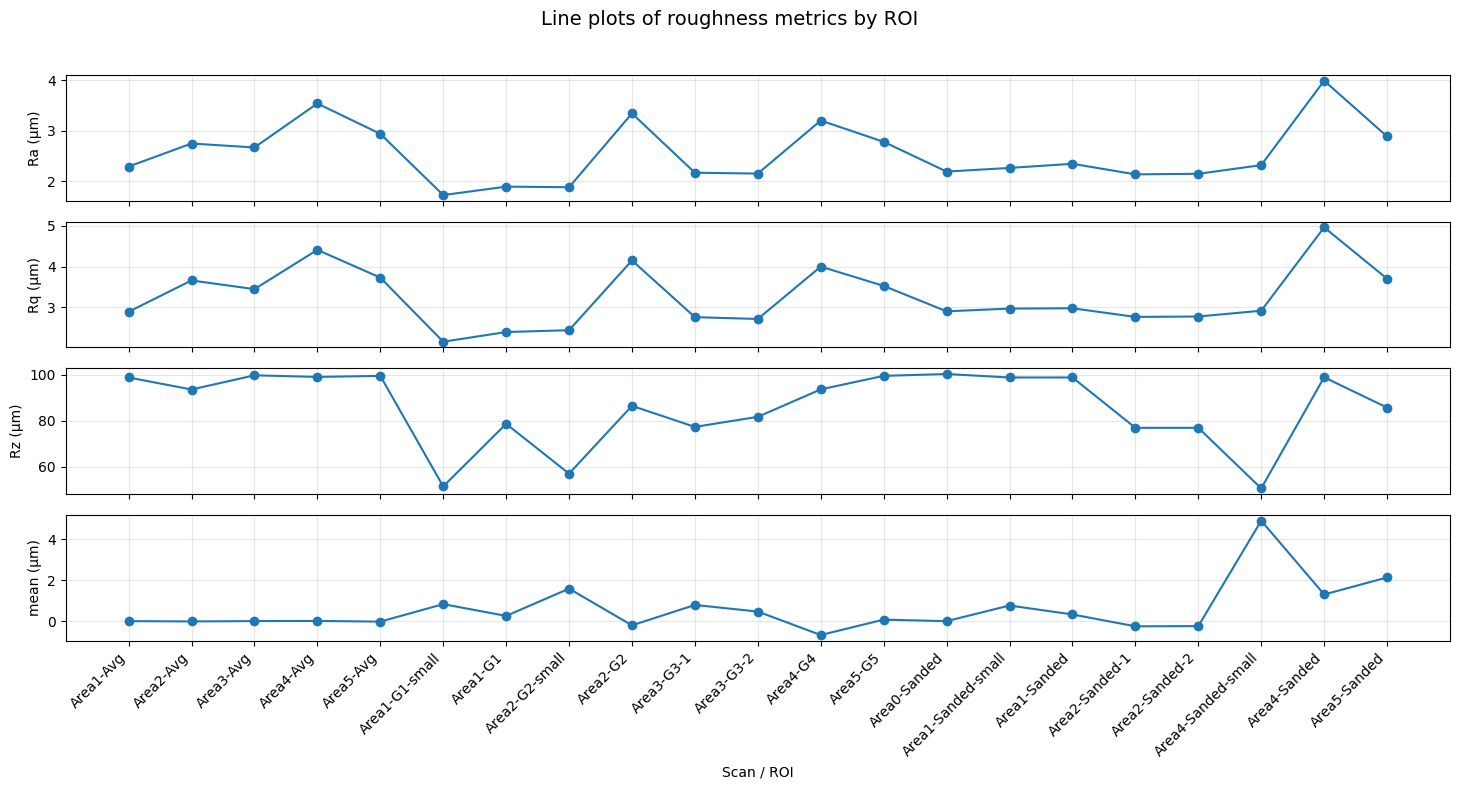

In [36]:
metric_names = ['Ra', 'Rq', 'Rz', 'mean']
fig_metrics, axes = plt.subplots(len(metric_names), 1,
                                 figsize=(max(8, len(combined_df) * 0.7), 2.0 * len(metric_names)),
                                 sharex=True)

x_vals = range(len(combined_df))
labels = combined_df['label']

for ax, metric in zip(axes, metric_names):
    ax.plot(x_vals, combined_df[metric], marker='o')
    ax.set_ylabel(f"{metric} (µm)")
    ax.grid(alpha=0.3)

axes[-1].set_xticks(list(x_vals))
axes[-1].set_xticklabels(labels, rotation=45, ha='right')
axes[-1].set_xlabel('Scan / ROI')
fig_metrics.suptitle('Line plots of roughness metrics by ROI', fontsize=14)
fig_metrics.tight_layout(rect=(0, 0, 1, 0.96))
fig_metrics



### 4.5 Heatmap of normalized metrics

A z-score heatmap highlights which ROIs deviate the most for each metric.

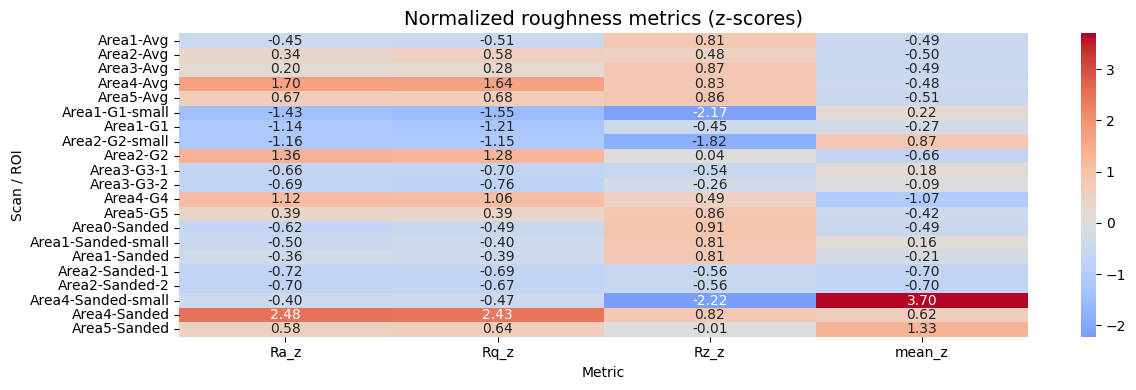

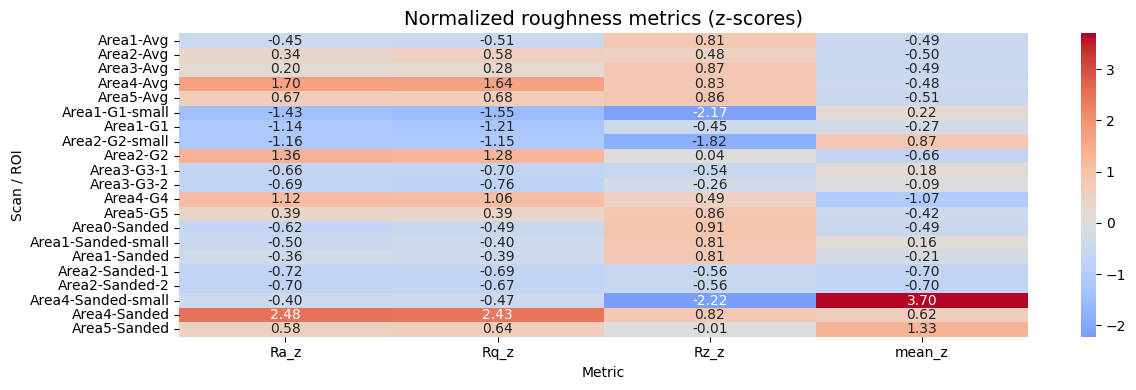

In [37]:
heatmap_data = combined_df.set_index('label')[['Ra_z', 'Rq_z', 'Rz_z', 'mean_z']]
fig_heatmap, ax_heatmap = plt.subplots(figsize=(max(6, heatmap_data.shape[0] * 0.6), 4))
sns.heatmap(heatmap_data, cmap='coolwarm', center=0, annot=True, fmt='.2f', ax=ax_heatmap)
ax_heatmap.set_title('Normalized roughness metrics (z-scores)', fontsize=14)
ax_heatmap.set_xlabel('Metric')
ax_heatmap.set_ylabel('Scan / ROI')
fig_heatmap.tight_layout()
fig_heatmap



### 4.6 Treatment comparison across scans

Box/strip plots show the spread of ``Rq`` for each treatment, and line plots track how ``Rq`` changes across scan areas.

Rq summary by treatment (µm):


,mean,std,count
treatment,,,
G4,3.999379,NaN,1
Avg,3.627057,0.547931,5
G5,3.525388,NaN,1
G2,3.294160,1.211817,2
Sanded,3.245507,0.754989,8
G3,2.735677,0.031663,2
G1,2.273557,0.168244,2


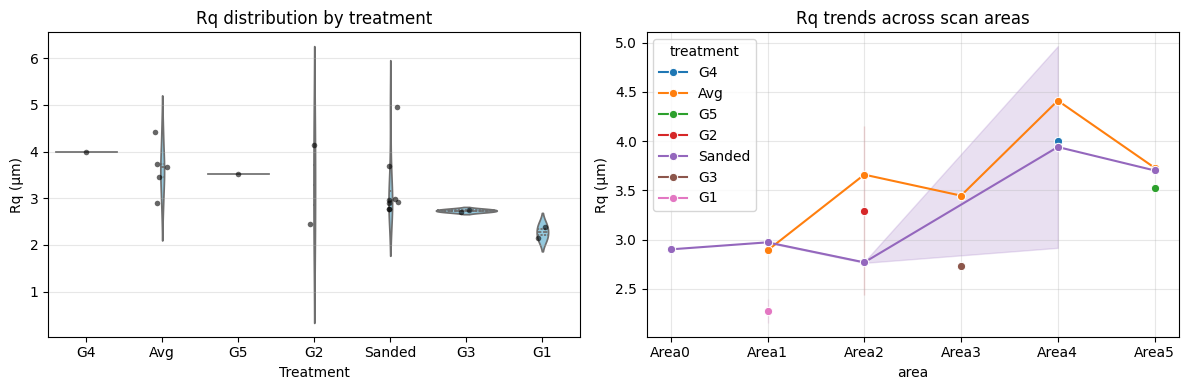

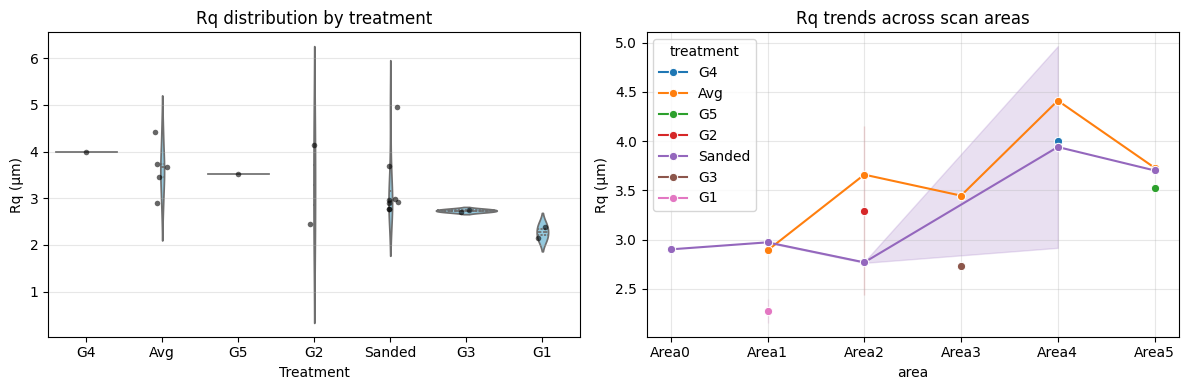

In [38]:
summary = (combined_df.groupby('treatment')['Rq']
           .agg(['mean', 'std', 'count'])
           .sort_values('mean', ascending=False))
print('Rq summary by treatment (µm):')
display(summary)

treatment_order = summary.index.tolist()

fig_compare, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

sns.violinplot(data=combined_df, x='treatment', y='Rq', order=treatment_order,
               inner='quartile', ax=axes[0], color='skyblue')
sns.stripplot(data=combined_df, x='treatment', y='Rq', order=treatment_order,
              ax=axes[0], color='black', size=4, alpha=0.6)
axes[0].set_title('Rq distribution by treatment')
axes[0].set_xlabel('Treatment')
axes[0].set_ylabel('Rq (µm)')
axes[0].grid(alpha=0.3, axis='y')

sns.lineplot(data=combined_df.sort_values('area'), x='area', y='Rq', hue='treatment',
             marker='o', ax=axes[1], hue_order=treatment_order)
axes[1].set_title('Rq trends across scan areas')
axes[1].set_ylabel('Rq (µm)')
axes[1].grid(alpha=0.3)
fig_compare.tight_layout()
fig_compare



### 4.7 Parallel coordinates plot

Compare all absolute roughness metrics per ROI on shared axes.

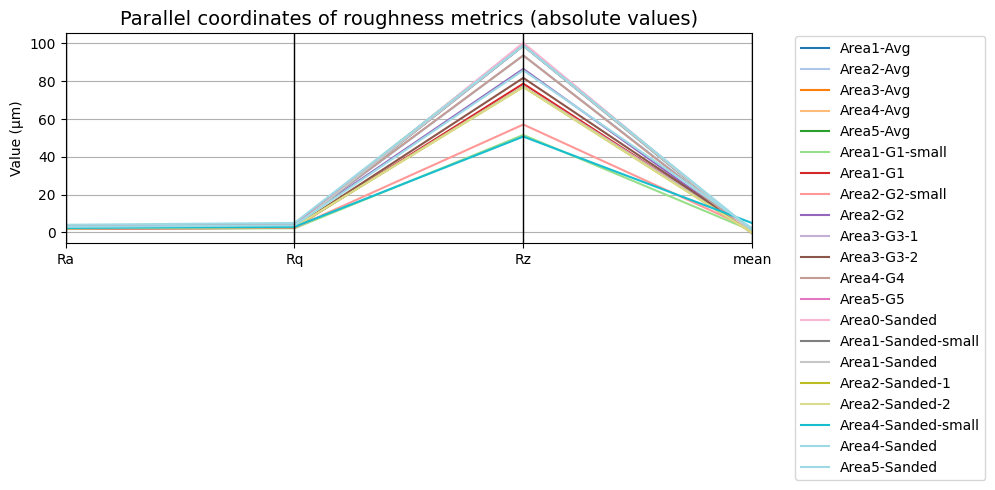

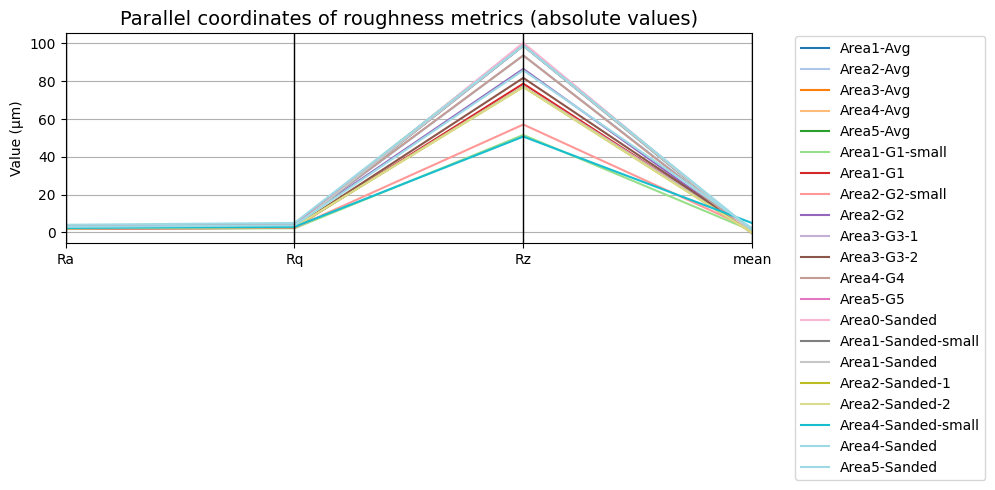

In [39]:
from pandas.plotting import parallel_coordinates

metric_names = ['Ra', 'Rq', 'Rz', 'mean']
parallel_df = combined_df[['label'] + metric_names].copy()
fig_parallel, ax_parallel = plt.subplots(figsize=(max(6, len(parallel_df) * 0.5), 4))
parallel_coordinates(parallel_df, 'label', ax=ax_parallel, colormap='tab20')
ax_parallel.set_title('Parallel coordinates of roughness metrics (absolute values)', fontsize=14)
ax_parallel.set_ylabel('Value (µm)')
ax_parallel.set_xticks(range(len(metric_names)))
ax_parallel.set_xticklabels(metric_names)
ax_parallel.legend(loc='upper right', bbox_to_anchor=(1.35, 1.02))
fig_parallel.tight_layout()
fig_parallel



### 4.8 PCA scatter plot

A two-component PCA of the normalized metrics reveals clusters or drifts in the combined roughness feature space.

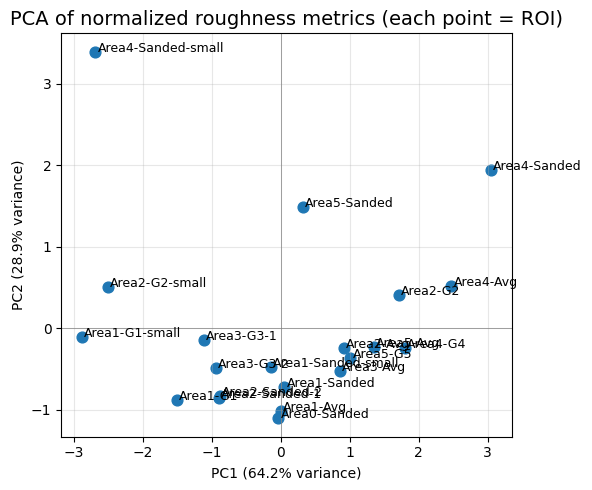

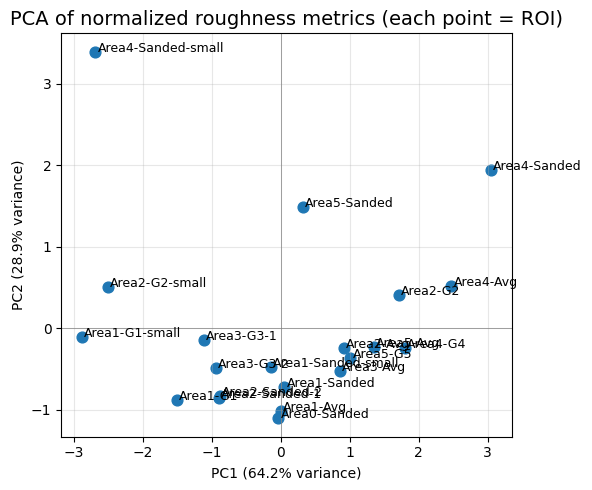

In [40]:
from sklearn.decomposition import PCA

metric_names = ['Ra', 'Rq', 'Rz', 'mean']
scaled_metrics = combined_df[[f'{c}_z' for c in metric_names]].values
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(scaled_metrics)
fig_pca, ax_pca = plt.subplots(figsize=(6, 5))
ax_pca.scatter(pca_coords[:, 0], pca_coords[:, 1], s=60)
for (x, y), label in zip(pca_coords, combined_df['label']):
    ax_pca.text(x + 0.03, y, label, fontsize=9)
ax_pca.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax_pca.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax_pca.set_title('PCA of normalized roughness metrics (each point = ROI)', fontsize=14)
ax_pca.axhline(0, color='grey', linewidth=0.5)
ax_pca.axvline(0, color='grey', linewidth=0.5)
ax_pca.grid(alpha=0.3)
fig_pca.tight_layout()
fig_pca

